In [25]:
# === 0. Imports & config ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import joblib
import shap
from tqdm import tqdm
import os

# display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [26]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/DA project/ecommerce_customer_data_custom_ratios.csv"

# Load CSV first without parsing dates
df = pd.read_csv(DATA_PATH)

# List possible purchase date column names
possible_date_cols = ["Purchase Date", "Purchase_Date", "purchase_date"]

# Find which column exists in the CSV
date_cols = [c for c in possible_date_cols if c in df.columns]

# Parse only the existing column(s)
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Normalize all column names to lowercase + underscores
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Check columns
print("Columns after normalization:", df.columns.tolist())
df.head()

Columns after normalization: ['customer_id', 'purchase_date', 'product_category', 'product_price', 'quantity', 'total_purchase_amount', 'payment_method', 'customer_age', 'returns', 'customer_name', 'age', 'gender', 'churn']


,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [27]:
# === 2. Basic cleaning & required column mapping ===
# We expect at least: customer_id, purchase_date, total_purchase_amount
# Try common alternative names
col_map = {}
if "customer_id" not in df.columns:
    # attempt common alternatives
    for alt in ["customerid", "customer", "cust_id"]:
        if alt in df.columns:
            col_map[alt] = "customer_id"
if "purchase_date" not in df.columns:
    for alt in ["purchase_date", "purchase_date", "order_date", "date"]:
        if alt in df.columns:
            col_map[alt] = "purchase_date"
if "total_purchase_amount" not in df.columns and "order_amount" not in df.columns and "total_amount" not in df.columns:
    for alt in ["total_purchase_amount", "order_amount", "total_amount", "price", "product_price"]:
        if alt in df.columns:
            col_map[alt] = "total_purchase_amount"

# Apply renames if found
if col_map:
    df = df.rename(columns=col_map)
    print("Renamed cols:", col_map)

# Ensure essential columns exist
required = ["customer_id", "purchase_date", "total_purchase_amount"]
for r in required:
    if r not in df.columns:
        raise ValueError(f"Required column '{r}' not found in dataset. Found columns: {df.columns.tolist()}")

# Ensure data types
df["purchase_date"] = pd.to_datetime(df["purchase_date"])
df["total_purchase_amount"] = pd.to_numeric(df["total_purchase_amount"], errors="coerce").fillna(0.0)
print("Dataset shape:", df.shape)

Dataset shape: (250000, 13)


In [28]:
# === 3. Quick EDA (optional) ===
print("Number of unique customers:", df["customer_id"].nunique())
print("Date range:", df["purchase_date"].min(), "to", df["purchase_date"].max())
print()
display(df.sample(5))
print()
print("Checking Duplicate value")
df.duplicated()

Number of unique customers: 49673
Date range: 2020-01-01 00:15:00 to 2023-09-15 12:24:08



,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn
38683,48828,2020-10-09 01:40:41,Electronics,480,3,4312,Cash,31,0.0,Mary Wilson,31,Female,1
64939,3715,2020-05-01 08:14:07,Electronics,74,1,4232,Crypto,45,0.0,Mrs. Tonya Rodriguez,45,Male,0
3954,37109,2020-04-03 05:28:17,Home,449,2,992,Cash,50,1.0,Justin Swanson,50,Female,1
120374,5376,2021-02-01 02:45:03,Clothing,364,3,2240,Credit Card,52,0.0,Alexa Davis,52,Male,0
172861,21706,2022-11-21 08:17:28,Clothing,354,2,416,PayPal,60,1.0,Christopher Archer,60,Male,0



Checking Duplicate value


,0
0,False
1,False
2,False
3,False
4,False
...,...
249995,False
249996,False
249997,False
249998,False


In [29]:
# === 4. Define cutoff (observation) date and prediction horizon ===
# Choose cutoff so that you have at least prediction_horizon days after it in the data
# By default we'll use last date minus 365 days as cutoff to allow 12-month future window available.
max_date = df["purchase_date"].max()
prediction_horizon_days = 365  # predict next 12 months
cutoff_date = max_date - pd.Timedelta(days=prediction_horizon_days)
print("Using cutoff_date (end of observation):", cutoff_date.date(),
      " — prediction horizon days:", prediction_horizon_days)

Using cutoff_date (end of observation): 2022-09-15  — prediction horizon days: 365


In [30]:
# === 5. Split history and future (target) windows ===
history = df[df["purchase_date"] <= cutoff_date].copy()
future = df[(df["purchase_date"] > cutoff_date) & (df["purchase_date"] <= cutoff_date + pd.Timedelta(days=prediction_horizon_days))].copy()
print("History rows:", len(history), "Future rows:", len(future))

History rows: 182690 Future rows: 67310


In [31]:
# === 6. Build target: future spend per customer in prediction window ===
target = future.groupby("customer_id")["total_purchase_amount"].sum().rename("future_spend_12m").reset_index()
# include customers who appear in history but have zero future spend
customers_history = history["customer_id"].unique()
target = pd.DataFrame({"customer_id": customers_history}).merge(target, on="customer_id", how="left")
target["future_spend_12m"] = target["future_spend_12m"].fillna(0.0)
print("Target rows:", target.shape[0])
target.head()

Target rows: 48716


,customer_id,future_spend_12m
0,46251,0.0
1,13593,2471.0
2,28805,1993.0
3,28961,7427.0
4,12163,7592.0


In [32]:
# === 7. Feature engineering on history window ===
# We'll create RFM + behavioral + demographic features
# Required columns we may use: product_category, quantity, returns, customer_age, gender, payment_method

# Basic RFM
agg_funcs = {
    "purchase_date": ["min", "max", "count"],
    "total_purchase_amount": ["sum", "mean", "std"]
}
# include quantity if present
if "quantity" in history.columns:
    agg_funcs["quantity"] = ["sum", "mean"]
if "returns" in history.columns:
    agg_funcs["returns"] = ["sum"]

hist_agg = history.groupby("customer_id").agg(agg_funcs)
# flatten columns
hist_agg.columns = ["_".join(col).strip() for col in hist_agg.columns.values]
hist_agg = hist_agg.reset_index()
# rename
hist_agg = hist_agg.rename(columns={
    "purchase_date_min": "first_purchase_date",
    "purchase_date_max": "last_purchase_date",
    "purchase_date_count": "num_orders",
    "total_purchase_amount_sum": "total_spent",
    "total_purchase_amount_mean": "avg_order_value",
    "total_purchase_amount_std": "std_order_value"
})
# fill std NaN with 0
hist_agg["std_order_value"] = hist_agg["std_order_value"].fillna(0.0)

# recency and tenure
hist_agg["recency_days"] = (cutoff_date - hist_agg["last_purchase_date"]).dt.days
hist_agg["tenure_days"] = (hist_agg["last_purchase_date"] - hist_agg["first_purchase_date"]).dt.days.clip(lower=1)

# frequency per month
hist_agg["orders_per_month"] = hist_agg["num_orders"] / (hist_agg["tenure_days"] / 30.0)

# quantity features
if "quantity_sum" in hist_agg.columns and "num_orders" in hist_agg.columns:
    hist_agg["avg_items_per_order"] = hist_agg["quantity_mean"].fillna(0.0)
else:
    hist_agg["avg_items_per_order"] = 0.0

# returns ratio
if "returns_sum" in hist_agg.columns:
    hist_agg["returns_ratio"] = hist_agg["returns_sum"] / hist_agg["num_orders"]
else:
    hist_agg["returns_ratio"] = 0.0

# product category diversity
if "product_category" in history.columns:
    cat_div = history.groupby("customer_id")["product_category"].nunique().rename("prod_category_count").reset_index()
    hist_agg = hist_agg.merge(cat_div, on="customer_id", how="left")
    hist_agg["prod_category_count"] = hist_agg["prod_category_count"].fillna(0).astype(int)
else:
    hist_agg["prod_category_count"] = 0

# preferred payment method (mode)
if "payment_method" in history.columns:
    pref_pay = history.groupby("customer_id")["payment_method"].agg(lambda x: x.mode().iat[0] if len(x.mode())>0 else np.nan).rename("preferred_payment_method").reset_index()
    hist_agg = hist_agg.merge(pref_pay, on="customer_id", how="left")
else:
    hist_agg["preferred_payment_method"] = np.nan

# demographics: age, gender (take most recent or mode)
if "customer_age" in history.columns:
    age = history.groupby("customer_id")["customer_age"].median().rename("customer_age").reset_index()
    hist_agg = hist_agg.merge(age, on="customer_id", how="left")
else:
    hist_agg["customer_age"] = np.nan

if "gender" in history.columns:
    gender = history.groupby("customer_id")["gender"].agg(lambda x: x.mode().iat[0] if len(x.mode())>0 else np.nan).rename("gender").reset_index()
    hist_agg = hist_agg.merge(gender, on="customer_id", how="left")
else:
    hist_agg["gender"] = np.nan

# Fill missing numeric demographics
hist_agg["customer_age"] = hist_agg["customer_age"].fillna(hist_agg["customer_age"].median(skipna=True))
hist_agg[["returns_ratio"]] = hist_agg[["returns_ratio"]].fillna(0.0)

print("Feature frame shape:", hist_agg.shape)
hist_agg.head(7)

Feature frame shape: (48716, 19)


,customer_id,first_purchase_date,last_purchase_date,num_orders,total_spent,avg_order_value,std_order_value,quantity_sum,quantity_mean,returns_sum,recency_days,tenure_days,orders_per_month,avg_items_per_order,returns_ratio,prod_category_count,preferred_payment_method,customer_age,gender
0,2,2021-03-05 14:30:42,2021-09-19 16:55:21,2,5169,2584.500000,2298.804146,5,2.500000,1.0,360,198,0.303030,2.500000,0.500000,1,PayPal,27.0,Female
1,3,2020-09-27 22:26:24,2022-01-17 05:47:30,6,16396,2732.666667,1796.495329,19,3.166667,3.0,241,476,0.378151,3.166667,0.500000,4,Credit Card,23.0,Female
2,4,2020-10-09 03:25:04,2022-02-07 08:00:52,3,4449,1483.000000,1473.306825,7,2.333333,1.0,220,486,0.185185,2.333333,0.333333,1,Credit Card,66.0,Male
3,5,2020-01-28 14:28:33,2021-12-14 20:07:43,5,9134,1826.800000,854.893970,24,4.800000,2.0,274,686,0.218659,4.800000,0.400000,3,Credit Card,26.0,Female
4,6,2020-01-19 18:25:00,2022-06-09 15:12:26,6,15517,2586.166667,1657.366636,11,1.833333,0.0,97,871,0.206659,1.833333,0.000000,4,Crypto,24.0,Female
5,7,2020-05-16 06:52:55,2022-02-27 07:52:37,3,7835,2611.666667,1852.459536,15,5.000000,1.0,200,652,0.138037,5.000000,0.333333,3,PayPal,34.0,Female
6,8,2020-05-29 23:08:30,2022-08-24 02:40:35,5,13893,2778.600000,1225.240099,12,2.400000,0.0,22,816,0.183824,2.400000,0.000000,3,Credit Card,50.0,Female


In [33]:
# === 8. Merge features with target & prepare model dataframe ===
data = hist_agg.merge(target, on="customer_id", how="left")
data["future_spend_12m"] = data["future_spend_12m"].fillna(0.0)

# drop date columns that leak
data = data.drop(columns=[c for c in ["first_purchase_date", "last_purchase_date"] if c in data.columns])

print("Model dataset shape:", data.shape)
data.head()

Model dataset shape: (48716, 18)


,customer_id,num_orders,total_spent,avg_order_value,std_order_value,quantity_sum,quantity_mean,returns_sum,recency_days,tenure_days,orders_per_month,avg_items_per_order,returns_ratio,prod_category_count,preferred_payment_method,customer_age,gender,future_spend_12m
0,2,2,5169,2584.500000,2298.804146,5,2.500000,1.0,360,198,0.303030,2.500000,0.500000,1,PayPal,27.0,Female,2819.0
1,3,6,16396,2732.666667,1796.495329,19,3.166667,3.0,241,476,0.378151,3.166667,0.500000,4,Credit Card,23.0,Female,6191.0
2,4,3,4449,1483.000000,1473.306825,7,2.333333,1.0,220,486,0.185185,2.333333,0.333333,1,Credit Card,66.0,Male,4266.0
3,5,5,9134,1826.800000,854.893970,24,4.800000,2.0,274,686,0.218659,4.800000,0.400000,3,Credit Card,26.0,Female,3390.0
4,6,6,15517,2586.166667,1657.366636,11,1.833333,0.0,97,871,0.206659,1.833333,0.000000,4,Crypto,24.0,Female,0.0


In [34]:
# === 9. Prepare X (features) and y (target). Handle categorical features ===
# Choose feature columns
exclude = {"customer_id", "future_spend_12m"}
feature_cols = [c for c in data.columns if c not in exclude]
print("Features used:", feature_cols)

X = data[feature_cols].copy()
y = data["future_spend_12m"].copy()

# Many targets are heavy-tailed; use log1p transform for modeling stability
y_log = np.log1p(y)

# Simple categorical encoding: one-hot for payment_method and gender (small cardinality)
cat_cols = [c for c in ["preferred_payment_method", "gender"] if c in X.columns]
num_cols = [c for c in X.columns if c not in cat_cols + ["customer_id"]]
print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# One-hot encode categorical
X_encoded = pd.get_dummies(X, columns=cat_cols, dummy_na=True, drop_first=True)
# Fill any remaining NaNs with 0
X_encoded = X_encoded.fillna(0.0)
print("Encoded feature shape:", X_encoded.shape)

Features used: ['num_orders', 'total_spent', 'avg_order_value', 'std_order_value', 'quantity_sum', 'quantity_mean', 'returns_sum', 'recency_days', 'tenure_days', 'orders_per_month', 'avg_items_per_order', 'returns_ratio', 'prod_category_count', 'preferred_payment_method', 'customer_age', 'gender']
Numeric cols: ['num_orders', 'total_spent', 'avg_order_value', 'std_order_value', 'quantity_sum', 'quantity_mean', 'returns_sum', 'recency_days', 'tenure_days', 'orders_per_month', 'avg_items_per_order', 'returns_ratio', 'prod_category_count', 'customer_age']
Categorical cols: ['preferred_payment_method', 'gender']
Encoded feature shape: (48716, 20)


In [35]:
# === 10. Train/validation/test split ===
customer_ids = data["customer_id"].reset_index(drop=True)
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y_log, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print(X_train.shape, X_val.shape, X_test.shape)

(34101, 20) (7307, 20) (7308, 20)


In [36]:
# === 11. Train XGBoost regressor with early stopping ===
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": RANDOM_STATE,
    "verbosity": 1
}

evals = [(dtrain, "train"), (dval, "val")]
model = xgb.train(params, dtrain, num_boost_round=2000, early_stopping_rounds=50, evals=evals, verbose_eval=50)
print("Best iteration:", model.best_iteration)

[0]	train-rmse:3.67090	val-rmse:3.71263
[50]	train-rmse:3.59945	val-rmse:3.71390
[53]	train-rmse:3.59649	val-rmse:3.71411
Best iteration: 3


In [37]:
# === 12. Evaluation helpers and metrics (convert back from log) ===
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import xgboost as xgb

def evaluate_model(mdl, X, y_log_true, label="set"):
    # Convert features to DMatrix
    d = xgb.DMatrix(X)

    # Predict
    y_log_pred = mdl.predict(d)

    # Convert from log back to actual scale
    y_true = np.expm1(y_log_true)
    y_pred = np.expm1(y_log_pred)

    # Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # <-- fixed here
    r2 = r2_score(y_true, y_pred)

    print(f"{label} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}")
    return y_true, y_pred

# Evaluate on validation and test sets
y_true_val, y_pred_val = evaluate_model(model, X_val, y_val, "Validation")
y_true_test, y_pred_test = evaluate_model(model, X_test, y_test, "Test")


Validation -> MAE: 3416.88, RMSE: 4783.06, R2: -0.778
Test -> MAE: 3428.93, RMSE: 4762.95, R2: -0.812


In [38]:
# === NEW: Baseline comparison — Linear Regression ===
from sklearn.linear_model import LinearRegression

lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)

lr_pred_log_test = lr_baseline.predict(X_test)
lr_true_test = np.expm1(y_test)
lr_pred_test = np.expm1(lr_pred_log_test)

lr_mae = mean_absolute_error(lr_true_test, lr_pred_test)
lr_rmse = np.sqrt(mean_squared_error(lr_true_test, lr_pred_test))
lr_r2 = r2_score(lr_true_test, lr_pred_test)

print(f"Linear Regression (baseline) -> MAE: {lr_mae:.2f}, RMSE: {lr_rmse:.2f}, R2: {lr_r2:.3f}")

# XGBoost test metrics for comparison (from cell 12 output above)
xgb_mae = mean_absolute_error(y_true_test, y_pred_test)
xgb_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
xgb_r2 = r2_score(y_true_test, y_pred_test)

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression (baseline)", "XGBoost"],
    "MAE": [lr_mae, xgb_mae],
    "RMSE": [lr_rmse, xgb_rmse],
    "R2": [lr_r2, xgb_r2]
})
print("\n=== Model Comparison ===")
print(comparison_df)

improvement_r2 = xgb_r2 - lr_r2
improvement_rmse_pct = (lr_rmse - xgb_rmse) / lr_rmse * 100
print(f"\nXGBoost improved R2 by {improvement_r2:.3f} and reduced RMSE by {improvement_rmse_pct:.1f}% vs. Linear Regression baseline")

Linear Regression (baseline) -> MAE: 3431.20, RMSE: 4766.90, R2: -0.815

=== Model Comparison ===
                          Model          MAE         RMSE        R2
0  Linear Regression (baseline)  3431.204017  4766.898431 -0.815338
1                       XGBoost  3428.926823  4762.948426 -0.812331

XGBoost improved R2 by 0.003 and reduced RMSE by 0.1% vs. Linear Regression baseline


In [39]:
# === 13. Business metric: Top-decile capture ===
def topk_capture(y_true, y_pred, k=0.1):
    n = len(y_pred)
    topk = int(np.ceil(n * k))
    idx = np.argsort(-y_pred)[:topk]  # top predicted
    captured = y_true[idx].sum() / y_true.sum() if y_true.sum() > 0 else 0.0
    return captured

print("Top-10% capture (validation):", topk_capture(np.array(y_true_val), np.array(y_pred_val), 0.1))
print("Top-10% capture (test):", topk_capture(np.array(y_true_test), np.array(y_pred_test), 0.1))

Top-10% capture (validation): 0.10518940372736599
Top-10% capture (test): 0.10419466951888062


In [40]:
# === 14. Save model and training artifacts ===
os.makedirs("artifacts", exist_ok=True)
joblib.dump(model, "artifacts/xgb_ltv_model.joblib")
# Save feature columns order and training median (if needed)
joblib.dump(X_encoded.columns.tolist(), "artifacts/feature_columns.joblib")
print("Saved model and feature list to artifacts/")

Saved model and feature list to artifacts/


In [41]:
# === 15. Create final predictions for all customers and save CSV ===
d_all = xgb.DMatrix(X_encoded)
pred_log_all = model.predict(d_all)
pred_all = np.expm1(pred_log_all)
out = pd.DataFrame({
    "customer_id": data["customer_id"],
    "predicted_ltv_12m": pred_all,
    "historical_total_spent": data["total_spent"],
    "num_orders": data["num_orders"]
})
out.to_csv("predicted_ltv_12m.csv", index=False)
print("Saved predicted_ltv_12m.csv (rows):", len(out))
out.head()

Saved predicted_ltv_12m.csv (rows): 48716


,customer_id,predicted_ltv_12m,historical_total_spent,num_orders
0,2,384.099854,5169,2
1,3,429.986298,16396,6
2,4,463.472137,4449,3
3,5,419.414917,9134,5
4,6,576.984802,15517,6


/tmp/ipykernel_1492/2791812570.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=True)


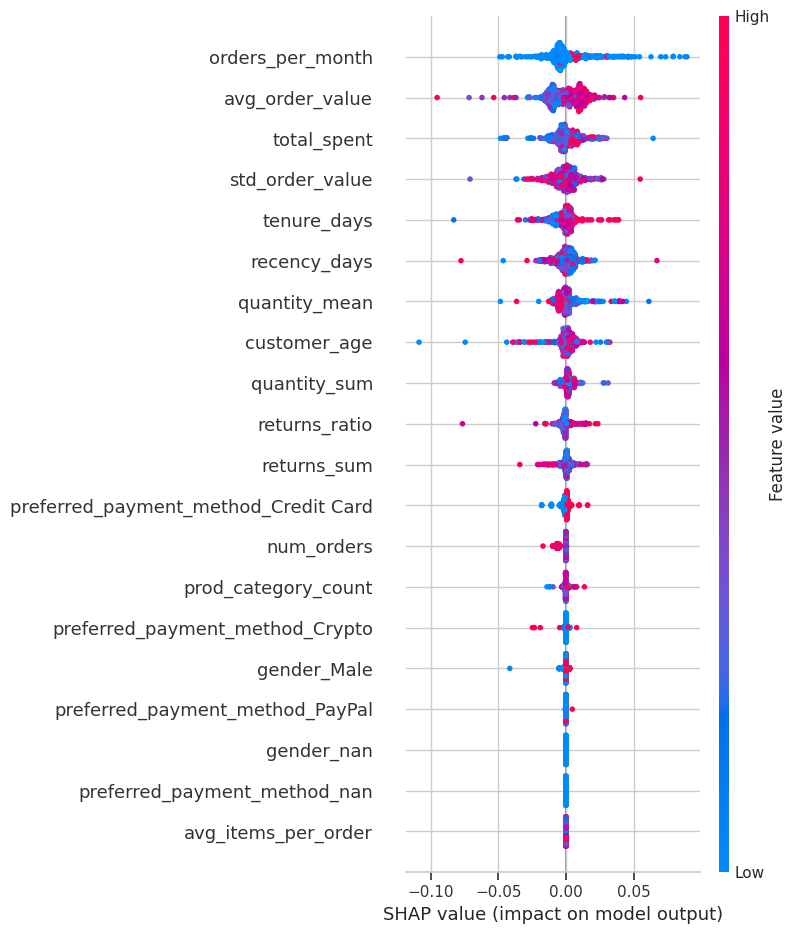

,feature,mean_abs_shap
9,orders_per_month,0.011195
2,avg_order_value,0.010212
1,total_spent,0.006799
3,std_order_value,0.006657
8,tenure_days,0.005749
7,recency_days,0.005331
5,quantity_mean,0.004930
13,customer_age,0.004783
4,quantity_sum,0.002863
11,returns_ratio,0.002679


In [42]:
# === 16. SHAP explanations (global & example local) ===
# Note: SHAP can be slow for large models/data. Do for sample or top features.
explainer = shap.Explainer(model)
# compute shap values on a sample to save time
sample_idx = np.random.choice(X_encoded.shape[0], min(500, X_encoded.shape[0]), replace=False)
X_sample = X_encoded.iloc[sample_idx]
shap_values = explainer(X_sample)

# summary plot (global)
shap.summary_plot(shap_values, X_sample, show=True)

# to display top features numerically
importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(20)
display(importance_df)

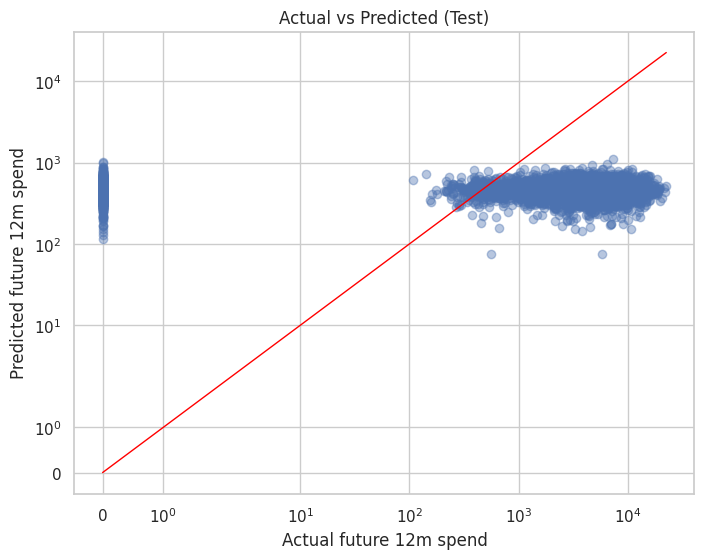

In [43]:
# === 17. Visualizations ===
# Actual vs Predicted (test)
plt.figure(figsize=(8,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.4)
plt.plot([0, max(y_true_test.max(), y_pred_test.max())],[0, max(y_true_test.max(), y_pred_test.max())], color='red', linewidth=1)
plt.xlabel("Actual future 12m spend")
plt.ylabel("Predicted future 12m spend")
plt.title("Actual vs Predicted (Test)")
plt.xscale("symlog")
plt.yscale("symlog")
plt.show()

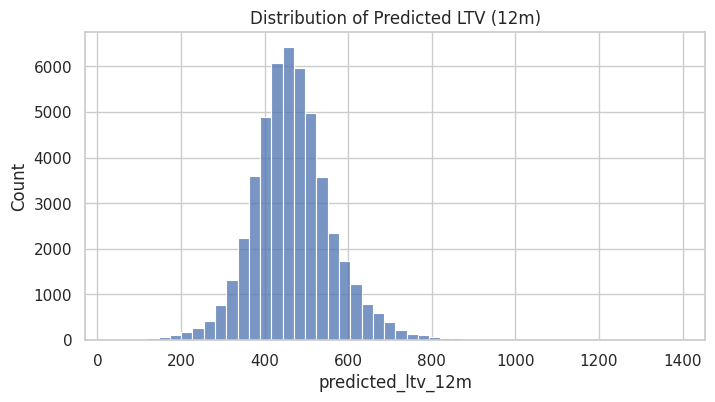

In [44]:
# Distribution of predicted LTV
plt.figure(figsize=(8,4))
sns.histplot(out["predicted_ltv_12m"], bins=50, kde=False)
plt.title("Distribution of Predicted LTV (12m)")
plt.show()

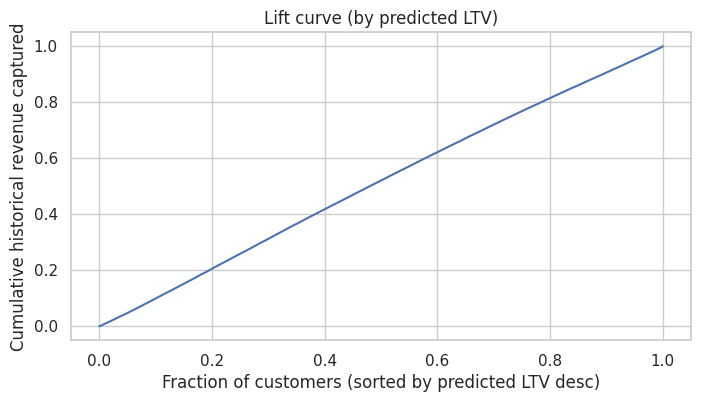

In [45]:
# Cumulative revenue capture by decile
deciles = out.copy()
deciles["pred_pct_rank"] = deciles["predicted_ltv_12m"].rank(pct=True)
deciles = deciles.sort_values("predicted_ltv_12m", ascending=False)
deciles["cum_actual"] = deciles["historical_total_spent"].cumsum()
deciles["cum_actual_pct"] = deciles["cum_actual"] / deciles["historical_total_spent"].sum()
plt.figure(figsize=(8,4))
plt.plot(np.arange(len(deciles))/len(deciles), deciles["cum_actual_pct"])
plt.xlabel("Fraction of customers (sorted by predicted LTV desc)")
plt.ylabel("Cumulative historical revenue captured")
plt.title("Lift curve (by predicted LTV)")
plt.show()

In [46]:
# === 18. Export model summary & README snippet (quick) ===
with open("artifacts/model_info.txt", "w") as f:
    f.write("XGBoost LTV model\n")
    f.write(f"Trained on: {pd.Timestamp.now()}\n")
    f.write(f"Cutoff date: {cutoff_date}\n")
    f.write(f"Prediction horizon days: {prediction_horizon_days}\n")
    f.write("Features used:\n")
    for c in X_encoded.columns:
        f.write(f"- {c}\n")
print("Wrote artifacts/model_info.txt")

Wrote artifacts/model_info.txt


In [50]:
# === 21. FIXED: Export predictions with REAL customer_id ===
predictions_df = pd.DataFrame({
    "customer_id": data.loc[X_test.index, "customer_id"].values, # FIXED: Convert to NumPy array
    "actual_ltv_12m": y_true_test.values, # FIXED: Convert to NumPy array
    "predicted_ltv_12m": y_pred_test
})
predictions_df.to_csv("predicted_ltv_12m.csv", index=False)

joblib.dump(model, "xgb_ltv_model.joblib")

print("predictions CSV and trained model saved successfully!")
predictions_df.head()

predictions CSV and trained model saved successfully!


,customer_id,actual_ltv_12m,predicted_ltv_12m
0,16539,0.0,299.765320
1,21105,0.0,510.951172
2,37495,384.0,467.654633
3,45977,8597.0,497.402100
4,33439,2457.0,529.024597
